In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
%matplotlib inline

In [2]:
!cat /content/iris.names

1. Title: Iris Plants Database
	Updated Sept 21 by C.Blake - Added discrepency information

2. Sources:
     (a) Creator: R.A. Fisher
     (b) Donor: Michael Marshall (MARSHALL%PLU@io.arc.nasa.gov)
     (c) Date: July, 1988

3. Past Usage:
   - Publications: too many to mention!!!  Here are a few.
   1. Fisher,R.A. "The use of multiple measurements in taxonomic problems"
      Annual Eugenics, 7, Part II, 179-188 (1936); also in "Contributions
      to Mathematical Statistics" (John Wiley, NY, 1950).
   2. Duda,R.O., & Hart,P.E. (1973) Pattern Classification and Scene Analysis.
      (Q327.D83) John Wiley & Sons.  ISBN 0-471-22361-1.  See page 218.
   3. Dasarathy, B.V. (1980) "Nosing Around the Neighborhood: A New System
      Structure and Classification Rule for Recognition in Partially Exposed
      Environments".  IEEE Transactions on Pattern Analysis and Machine
      Intelligence, Vol. PAMI-2, No. 1, 67-71.
      -- Results:
         -- very low misclassification rates (0% for t

In [3]:
df = pd.read_csv('/content/iris.data', header=None)
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = df.drop(['class'], axis=1)
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Kernel Feature Space
Compute the centered and normalized homogeneous quadratic kernel matrix K for the iris dataset using the kernel function in input space.

In [7]:
X = df.values
K = (X @ X.T) ** 2 # quadratic_kernel_matrix

K

array([[1620.8676, 1405.5001, 1371.2209, ..., 2634.7689, 2656.3716,
        2312.6481],
       [1405.5001, 1225.7001, 1189.5601, ..., 2355.1609, 2361.96  ,
        2062.0681],
       [1371.2209, 1189.5601, 1160.0836, ..., 2238.2361, 2256.25  ,
        1964.2624],
       ...,
       [2634.7689, 2355.1609, 2238.2361, ..., 6771.6441, 6918.9124,
        6001.6009],
       [2656.3716, 2361.96  , 2256.25  , ..., 6918.9124, 7131.8025,
        6155.9716],
       [2312.6481, 2062.0681, 1964.2624, ..., 6001.6009, 6155.9716,
        5337.7636]])

In [8]:
n, _ = K.shape

N = np.ones((n, n)) / n
K_center = (np.eye(n) - N) @ K @ (np.eye(n) - N)

norm_matrix = np.diag(1 / np.sqrt(np.diag(K_center)))

KCN = norm_matrix @ K_center @ norm_matrix

KCN

array([[ 1.        ,  0.98497822,  0.98693098, ..., -0.98614805,
        -0.92901408, -0.94755109],
       [ 0.98497822,  1.        ,  0.99814509, ..., -0.99384118,
        -0.94877739, -0.92467013],
       [ 0.98693098,  0.99814509,  1.        , ..., -0.99297623,
        -0.932648  , -0.91110281],
       ...,
       [-0.98614805, -0.99384118, -0.99297623, ...,  1.        ,
         0.95798431,  0.92690398],
       [-0.92901408, -0.94877739, -0.932648  , ...,  0.95798431,
         1.        ,  0.95328264],
       [-0.94755109, -0.92467013, -0.91110281, ...,  0.92690398,
         0.95328264,  1.        ]])

In [9]:
KCN.shape

(150, 150)

Next, explicitly transform each point $x_i$ to the feature space $\phi(x_i)$, using the homogeneous quadratic kernel. Center these points and normalize them. Finally verify that the pair-wise dot products of the centered and normalized points in feature space yield the same kernel matrix computed directly in input space via the kernel function. To do this, compute the matrix difference between the kernel matrices from the two approaches, and then print the sum of the differences.

In [10]:
n, d = df.shape

In [11]:
features = df ** 2

for i, j in itertools.combinations(range(d), 2):
  features = pd.concat([features, np.sqrt(2) * df.iloc[:, i] * df.iloc[:, j]], axis=1, ignore_index=True)

features

,0,1,2,3,4,5,6,7,8,9
0,26.01,12.25,1.96,0.04,25.243712,10.097485,1.442498,6.929646,0.989949,0.395980
1,24.01,9.00,1.96,0.04,20.788939,9.701505,1.385929,5.939697,0.848528,0.395980
2,22.09,10.24,1.69,0.04,21.269772,8.640845,1.329361,5.883128,0.905097,0.367696
3,21.16,9.61,2.25,0.04,20.166685,9.758074,1.301076,6.576093,0.876812,0.424264
4,25.00,12.96,1.96,0.04,25.455844,9.899495,1.414214,7.127636,1.018234,0.395980
...,...,...,...,...,...,...,...,...,...,...
145,44.89,9.00,27.04,5.29,28.425693,49.271201,21.793031,22.061732,9.758074,16.913994
146,39.69,6.25,25.00,3.61,22.273864,44.547727,16.928136,17.677670,6.717514,13.435029
147,42.25,9.00,27.04,4.00,27.577164,47.800418,18.384776,22.061732,8.485281,14.707821
148,38.44,11.56,29.16,5.29,29.811622,47.347870,20.166685,25.964961,11.059150,17.564532


In [12]:
points = features.apply(lambda x: x - x.mean(), axis=0).apply(lambda x: x / np.linalg.norm(x), axis=1)
points

,0,1,2,3,4,5,6,7,8,9
0,-0.268326,0.083287,-0.464475,-0.060124,0.001871,-0.692522,-0.279692,-0.269436,-0.122400,-0.237313
1,-0.316250,-0.015020,-0.446202,-0.057759,-0.128460,-0.676856,-0.270343,-0.287782,-0.121720,-0.227977
2,-0.357119,0.020367,-0.435474,-0.055390,-0.109709,-0.678840,-0.260842,-0.277566,-0.115142,-0.219421
3,-0.390864,0.002755,-0.428170,-0.056498,-0.143454,-0.660467,-0.266870,-0.263300,-0.118254,-0.222193
4,-0.295108,0.103508,-0.458324,-0.059328,0.008217,-0.689298,-0.276838,-0.259921,-0.119930,-0.234170
...,...,...,...,...,...,...,...,...,...,...
145,0.367131,-0.018738,0.358218,0.119455,0.118316,0.599025,0.407151,0.229083,0.173154,0.318138
146,0.273503,-0.183503,0.437439,0.089662,-0.163527,0.657728,0.354031,0.106599,0.095933,0.294754
147,0.319766,-0.022124,0.422947,0.085480,0.103149,0.643922,0.333930,0.270478,0.149624,0.280605
148,0.134588,0.076200,0.444612,0.121939,0.172385,0.539866,0.355060,0.379193,0.225204,0.348980


In [13]:
KCN_2 = points @ points.T
KCN_2

,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
0,1.000000,0.984978,0.986931,0.977287,0.999335,0.976525,0.986764,0.998468,0.960655,0.988365,...,-0.973478,-0.933653,-0.900941,-0.978876,-0.959908,-0.960545,-0.962471,-0.986148,-0.929014,-0.947551
1,0.984978,1.000000,0.998145,0.996320,0.982830,0.925409,0.992734,0.991939,0.991336,0.999051,...,-0.985385,-0.960448,-0.837159,-0.995404,-0.980613,-0.972813,-0.913545,-0.993841,-0.948777,-0.924670
2,0.986931,0.998145,1.000000,0.998381,0.986940,0.931693,0.998124,0.993882,0.992756,0.998113,...,-0.981651,-0.962893,-0.828312,-0.991120,-0.973329,-0.973256,-0.923077,-0.992976,-0.932648,-0.911103
3,0.977287,0.996320,0.998381,1.000000,0.977835,0.912839,0.996364,0.987297,0.997534,0.996132,...,-0.981870,-0.971478,-0.802385,-0.990691,-0.974760,-0.976424,-0.910105,-0.991430,-0.929716,-0.892909
4,0.999335,0.982830,0.986940,0.977835,1.000000,0.977563,0.988830,0.998150,0.961090,0.986870,...,-0.971088,-0.935784,-0.893096,-0.975811,-0.955586,-0.961007,-0.966474,-0.984981,-0.919137,-0.937240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,-0.960545,-0.972813,-0.973256,-0.976424,-0.961007,-0.901074,-0.969523,-0.970367,-0.969549,-0.979694,...,0.993796,0.993376,0.820993,0.982146,0.987416,1.000000,0.924854,0.990559,0.947055,0.886488
146,-0.962471,-0.913545,-0.923077,-0.910105,-0.966474,-0.982755,-0.932903,-0.954854,-0.880419,-0.926456,...,0.923630,0.887582,0.915406,0.911671,0.894413,0.924854,1.000000,0.934969,0.845738,0.892296
147,-0.986148,-0.993841,-0.992976,-0.991430,-0.984981,-0.933707,-0.988680,-0.992413,-0.982935,-0.997153,...,0.996666,0.976402,0.856332,0.996388,0.990375,0.990559,0.934969,1.000000,0.957984,0.926904
148,-0.929014,-0.948777,-0.932648,-0.929716,-0.919137,-0.863162,-0.913559,-0.934166,-0.922845,-0.949783,...,0.970902,0.923496,0.866272,0.968832,0.983462,0.947055,0.845738,0.957984,1.000000,0.953283


In [14]:
sum_of_dif = (KCN - KCN_2).sum().sum()
sum_of_dif

-1.1407815881173122e-12

# Principal Components of Kernel Matrix
Compute the principal components (PCs) of the centered and normalized kernel matrix computed above. *Note*: in Python you may use **numpy.linalg.eig**; in R you may use **eigen**.

How many components are required to capture 90% of the total variance?

Project each of the original points/rows of **$K$** onto the first two PCs and create a scatter plot of the projected points. What is the range of values in each PC dimension?

In [15]:
w, v = np.linalg.eig(KCN)

w = w.real
v = v.real

In [16]:
num_components = (w.cumsum() / w.sum() >= 0.9).argmax() + 1
num_components

2

In [17]:
pc1 = v[:, 0]
pc2 = v[:, 1]

In [18]:
pc1_coord = KCN @ pc1
pc2_coord = KCN @ pc2

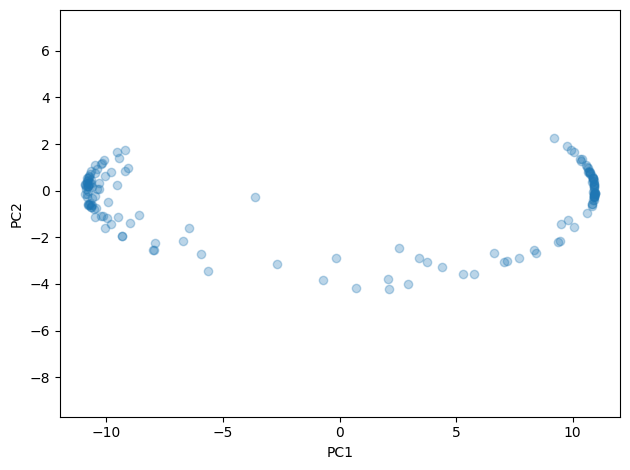

In [19]:
fig, ax = plt.subplots()
ax.scatter(pc1_coord, pc2_coord, alpha=0.3)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.axis('equal')
plt.tight_layout()
plt.show()